In [1]:
import numpy as np
import pyaudio

volume = 0.5
fs = 48000
duration = 5.0
f = 440.0       # 라 음

data = (np.sin(2 * np.pi * np.arange(fs*duration) * f/fs)).astype(np.float32)

p = pyaudio.PyAudio()
stream = p.open(format=pyaudio.paFloat32, channels=1, rate=fs, output=True)
stream.write(volume * data)

stream.stop_stream()
stream.close()
p.terminate()

In [4]:
print(len(data))

240000


In [5]:
print(data)

[ 0.          0.05756403  0.11493715 ... -0.1719291  -0.11493715
 -0.05756403]


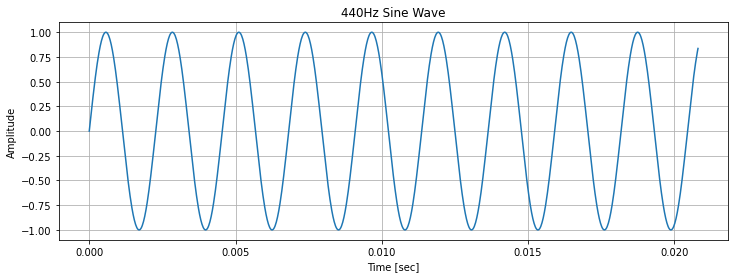

In [7]:
import matplotlib.pyplot as plt
t = np.arange(fs * duration) / fs
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], data[:1000])
plt.title("440Hz Sine Wave")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [15]:
class Tone:
    def __init__(self, volume=0.5, rate=48000, channels=1):
        self.volume = volume
        self.rate = rate
        self.channels = channels
        self.p = pyaudio.PyAudio()
        self.stream = p.open(format=pyaudio.paFloat32, channels=self.channels, rate=self.rate, output=True)

    def play(self, octave=3, note=1, duration=2):
        f = 2**(octave) * 55 * 2**(((note)-10)/12)
        sample = (np.sin(2 * np.pi * np.arange(self.rate*duration) * f/self.rate)).astype(np.float32)
        self.stream.write(self.volume * sample)

    def stop(self):
        self.stream.stop_stream()
        self.stream.close()
        self.p.terminate()

In [16]:
tone = Tone()
for n in [1, 3, 5, 7, 8, 10, 12]:
    tone.play(3, n, 4)
tone.stop()

In [11]:
import numpy as np
import pyaudio


class Tone:
    def __init__(self, volume=0.5, rate=48000, channels=1):
        self.volume = volume
        self.rate = rate
        self.channels = channels

        self.p = pyaudio.PyAudio()
        self.stream = self.p.open(
            format=pyaudio.paFloat32,
            channels=self.channels,
            rate=self.rate,
            output=True
        )

    def play(self, octave=3, note=1, duration=2):
        f = 2 ** octave * 55 * 2 ** ((note - 10) / 12)

        sample_count = int(self.rate * duration)
        t = np.arange(sample_count) / self.rate

        sample = np.sin(2 * np.pi * f * t).astype(np.float32)

        # 클릭음 방지를 위한 fade in / fade out
        fade_time = 0.01  # 10ms
        fade_samples = int(self.rate * fade_time)

        if fade_samples * 2 < sample_count:
            fade_in = np.linspace(0.0, 1.0, fade_samples)
            fade_out = np.linspace(1.0, 0.0, fade_samples)

            sample[:fade_samples] *= fade_in
            sample[-fade_samples:] *= fade_out

        sample = (self.volume * sample).astype(np.float32)

        self.stream.write(sample.tobytes())

    def stop(self):
        self.stream.stop_stream()
        self.stream.close()
        self.p.terminate()


tone = Tone()

for n in [1, 3, 5, 7, 8, 10, 12]:
    tone.play(3, n, 0.5)

tone.stop()

In [12]:
import numpy as np
import pyaudio
import time


class Tone:
    NOTE_TABLE = {
        "C": 0,
        "C#": 1,
        "Db": 1,
        "D": 2,
        "D#": 3,
        "Eb": 3,
        "E": 4,
        "F": 5,
        "F#": 6,
        "Gb": 6,
        "G": 7,
        "G#": 8,
        "Ab": 8,
        "A": 9,
        "A#": 10,
        "Bb": 10,
        "B": 11,
    }

    def __init__(self, volume=0.5, rate=48000):
        self.volume = volume
        self.rate = rate
        self.p = pyaudio.PyAudio()
        self.stream = self.p.open(
            format=pyaudio.paFloat32,
            channels=1,
            rate=self.rate,
            output=True
        )

    def note_to_freq(self, note_name):
        """
        예:
        A4 = 440Hz
        C4 = 도
        D4 = 레
        R  = 쉼표
        """
        if note_name == "R":
            return 0

        if len(note_name) == 2:
            name = note_name[0]
            octave = int(note_name[1])
        else:
            name = note_name[:-1]
            octave = int(note_name[-1])

        semitone = self.NOTE_TABLE[name]

        # MIDI 번호 계산
        # C4 = 60, A4 = 69
        midi_number = (octave + 1) * 12 + semitone

        # A4 = 440Hz 기준
        freq = 440.0 * (2 ** ((midi_number - 69) / 12))
        return freq

    def make_wave(self, freq, duration):
        sample_count = int(self.rate * duration)

        if freq == 0:
            return np.zeros(sample_count, dtype=np.float32)

        t = np.arange(sample_count) / self.rate
        sample = np.sin(2 * np.pi * freq * t).astype(np.float32)

        # 클릭음 방지용 fade in/out
        fade_time = 0.01
        fade_samples = int(self.rate * fade_time)

        if fade_samples * 2 < sample_count:
            fade_in = np.linspace(0.0, 1.0, fade_samples)
            fade_out = np.linspace(1.0, 0.0, fade_samples)

            sample[:fade_samples] *= fade_in
            sample[-fade_samples:] *= fade_out

        return sample

    def play_note(self, note_name, duration):
        freq = self.note_to_freq(note_name)
        sample = self.make_wave(freq, duration)
        sample = (self.volume * sample).astype(np.float32)
        self.stream.write(sample.tobytes())

    def play_melody(self, melody):
        """
        melody 형식:
        [
            ("C4", 0.5),
            ("D4", 0.5),
            ("E4", 1.0),
            ("R", 0.3),
        ]
        """
        for note_name, duration in melody:
            self.play_note(note_name, duration)

    def stop(self):
        self.stream.stop_stream()
        self.stream.close()
        self.p.terminate()


# 스타워즈 느낌의 오리지널 우주 팡파르 예제
space_fanfare = [
    ("G3", 0.45),
    ("G3", 0.45),
    ("G3", 0.45),

    ("C4", 1.20),
    ("G4", 1.20),

    ("F4", 0.35),
    ("E4", 0.35),
    ("D4", 0.35),
    ("C5", 1.20),

    ("G4", 0.60),
    ("F4", 0.35),
    ("E4", 0.35),
    ("D4", 0.35),
    ("C5", 1.20),

    ("G4", 0.70),
    ("F4", 0.35),
    ("E4", 0.35),
    ("F4", 0.35),
    ("D4", 1.00),

    ("R", 0.30),

    ("G3", 0.35),
    ("G3", 0.35),
    ("G3", 0.35),
    ("C4", 1.50),
]


tone = Tone(volume=0.4)

tone.play_melody(space_fanfare)

tone.stop()

In [14]:
import time
import numpy as np
import pyaudio


class Tone:
    NOTE_TABLE = {
        "C": 0,
        "C#": 1,
        "Db": 1,
        "D": 2,
        "D#": 3,
        "Eb": 3,
        "E": 4,
        "F": 5,
        "F#": 6,
        "Gb": 6,
        "G": 7,
        "G#": 8,
        "Ab": 8,
        "A": 9,
        "A#": 10,
        "Bb": 10,
        "B": 11,
    }

    def __init__(self, volume=0.5, rate=48000, channels=1, output_device_index=None):
        self.volume = volume
        self.rate = rate
        self.channels = channels
        self.output_device_index = output_device_index

        self.p = pyaudio.PyAudio()
        self.stream = None

        self.audio_data = np.array([], dtype=np.float32)
        self.position = 0

    def print_output_devices(self):
        print("=== Output devices ===")
        for i in range(self.p.get_device_count()):
            info = self.p.get_device_info_by_index(i)
            if info["maxOutputChannels"] > 0:
                print(i, info["name"], info["maxOutputChannels"], info["defaultSampleRate"])

    def note_to_freq(self, note_name):
        if note_name == "R":
            return 0

        if len(note_name) == 2:
            name = note_name[0]
            octave = int(note_name[1])
        else:
            name = note_name[:-1]
            octave = int(note_name[-1])

        semitone = self.NOTE_TABLE[name]

        # C4 = 60, A4 = 69
        midi_number = (octave + 1) * 12 + semitone

        # A4 = 440Hz
        freq = 440.0 * (2 ** ((midi_number - 69) / 12))
        return freq

    def make_wave(self, freq, duration):
        sample_count = int(self.rate * duration)

        if freq == 0:
            return np.zeros(sample_count, dtype=np.float32)

        t = np.arange(sample_count) / self.rate
        sample = np.sin(2 * np.pi * freq * t).astype(np.float32)

        # 틱틱 소리 방지용 fade in / fade out
        fade_time = 0.01
        fade_samples = int(self.rate * fade_time)

        if fade_samples * 2 < sample_count:
            fade_in = np.linspace(0.0, 1.0, fade_samples).astype(np.float32)
            fade_out = np.linspace(1.0, 0.0, fade_samples).astype(np.float32)

            sample[:fade_samples] *= fade_in
            sample[-fade_samples:] *= fade_out

        return sample

    def make_melody_data(self, melody):
        """
        melody 예:
        [
            ("C4", 0.5),
            ("D4", 0.5),
            ("E4", 1.0),
            ("R", 0.3),
        ]
        """
        waves = []

        for note_name, duration in melody:
            freq = self.note_to_freq(note_name)
            sample = self.make_wave(freq, duration)
            waves.append(sample)

        if len(waves) == 0:
            return np.array([], dtype=np.float32)

        audio_data = np.concatenate(waves)
        audio_data = (self.volume * audio_data).astype(np.float32)

        return audio_data

    def play_callback(self, in_data, frame_count, time_info, status):
        end_position = self.position + frame_count

        chunk = self.audio_data[self.position:end_position]
        self.position = end_position

        if len(chunk) < frame_count:
            remain = frame_count - len(chunk)
            chunk = np.pad(chunk, (0, remain), mode="constant")
            return (chunk.astype(np.float32).tobytes(), pyaudio.paComplete)

        return (chunk.astype(np.float32).tobytes(), pyaudio.paContinue)

    def play_melody(self, melody):
        self.audio_data = self.make_melody_data(melody)
        self.position = 0

        if self.stream is not None:
            if self.stream.is_active():
                self.stream.stop_stream()
            self.stream.close()

        self.stream = self.p.open(
            format=pyaudio.paFloat32,
            channels=self.channels,
            rate=self.rate,
            output=True,
            output_device_index=self.output_device_index,
            stream_callback=self.play_callback
        )

        self.stream.start_stream()

    def is_playing(self):
        if self.stream is None:
            return False

        return self.stream.is_active()

    def stop(self):
        if self.stream is not None:
            if self.stream.is_active():
                self.stream.stop_stream()
            self.stream.close()
            self.stream = None

    def close(self):
        self.stop()
        self.p.terminate()

space_fanfare = [
    ("G3", 0.35),
    ("G3", 0.35),
    ("G3", 0.35),

    ("C4", 1.00),
    ("G4", 1.00),

    ("F4", 0.30),
    ("E4", 0.30),
    ("D4", 0.30),
    ("C5", 1.00),

    ("G4", 0.50),
    ("F4", 0.30),
    ("E4", 0.30),
    ("D4", 0.30),
    ("C5", 1.00),

    ("G4", 0.70),
    ("F4", 0.30),
    ("E4", 0.30),
    ("F4", 0.30),
    ("D4", 1.00),

    ("R", 0.30),

    ("G3", 0.30),
    ("G3", 0.30),
    ("G3", 0.30),
    ("C4", 1.20),
]

tone = Tone(volume=0.4)

# 장치 번호 확인이 필요하면 실행
tone.print_output_devices()

tone.play_melody(space_fanfare)

while tone.is_playing():
    print("main work...")
    time.sleep(0.1)

tone.close()

=== Output devices ===
0 tegra-hda-xnx: HDMI 0 (hw:0,3) 8 44100.0
1 tegra-hda-xnx: HDMI 0 (hw:0,7) 8 44100.0
2 tegra-hda-xnx: HDMI 0 (hw:0,8) 8 44100.0
3 tegra-hda-xnx: HDMI 0 (hw:0,9) 8 44100.0
4 jetson-xaviernx-ape: - (hw:1,0) 16 44100.0
5 jetson-xaviernx-ape: - (hw:1,1) 16 44100.0
6 jetson-xaviernx-ape: - (hw:1,2) 16 44100.0
7 jetson-xaviernx-ape: - (hw:1,3) 16 44100.0
8 jetson-xaviernx-ape: - (hw:1,4) 16 44100.0
9 jetson-xaviernx-ape: - (hw:1,5) 16 44100.0
10 jetson-xaviernx-ape: - (hw:1,6) 16 44100.0
11 jetson-xaviernx-ape: - (hw:1,7) 16 44100.0
12 jetson-xaviernx-ape: - (hw:1,8) 16 44100.0
13 jetson-xaviernx-ape: - (hw:1,9) 16 44100.0
14 jetson-xaviernx-ape: - (hw:1,10) 16 44100.0
15 jetson-xaviernx-ape: - (hw:1,11) 16 44100.0
16 jetson-xaviernx-ape: - (hw:1,12) 16 44100.0
17 jetson-xaviernx-ape: - (hw:1,13) 16 44100.0
18 jetson-xaviernx-ape: - (hw:1,14) 16 44100.0
19 jetson-xaviernx-ape: - (hw:1,15) 16 44100.0
20 jetson-xaviernx-ape: - (hw:1,16) 16 44100.0
21 jetson-xaviernx-ape